In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
min(len(w) for w in words)

2

In [4]:
max(len(w) for w in words)

15

In [10]:
b = {}
for w in words[:3]:
    chs = ['<S>']+list(w) +['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):  #chs-><S> chs[1:]-><e>
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) +1 #.get returns count if none return 0 and add 1 regardless 
        print(ch1,ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


In [11]:
b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [36]:
import torch


In [37]:
N=torch.zeros((28,28), dtype=torch.int32)  #26 char + 2 special chars

In [18]:
N[1,3] +=1

In [39]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)} #integer index and actual element of the list-enumerate-->mapping char to integer
stoi['<S>'] = 26
stoi['<E>'] = 27

In [40]:
stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [42]:
for w in words:
    chs = ['<S>']+list(w) +['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):  #chs-><S> chs[1:]-><e>
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) +1 #.get returns count if none return 0 and add 1 regardless 
        # print(ch1,ch2)

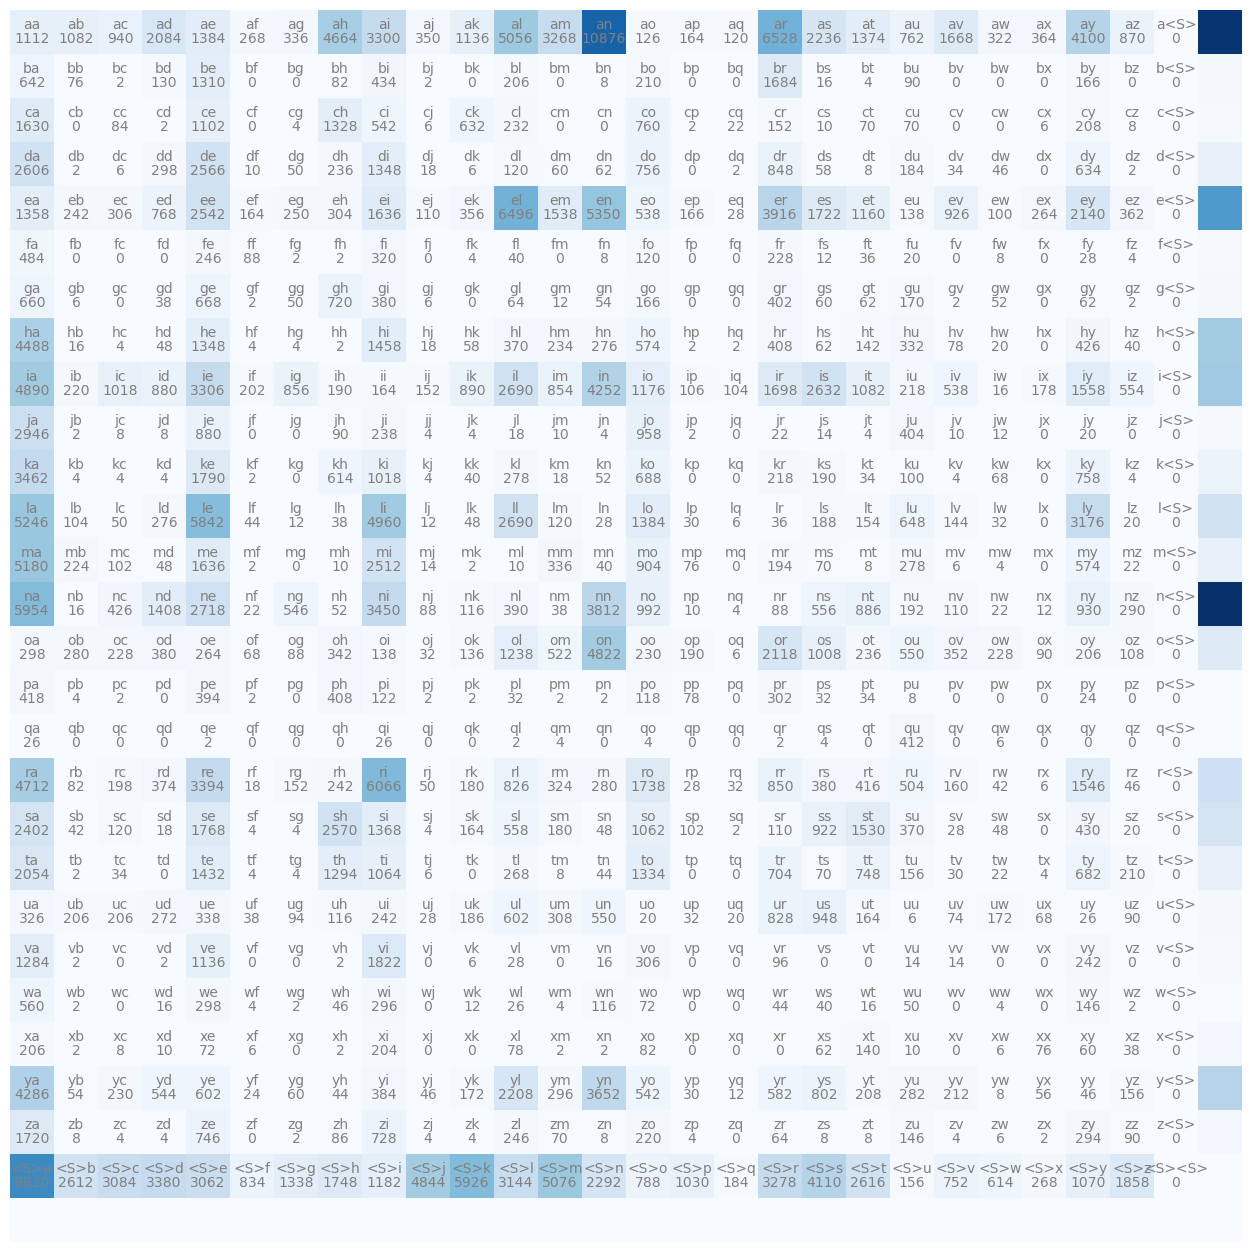

In [43]:
import matplotlib.pyplot as plt
%matplotlib inline
itos = {i:s for s,i in stoi.items()}
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');


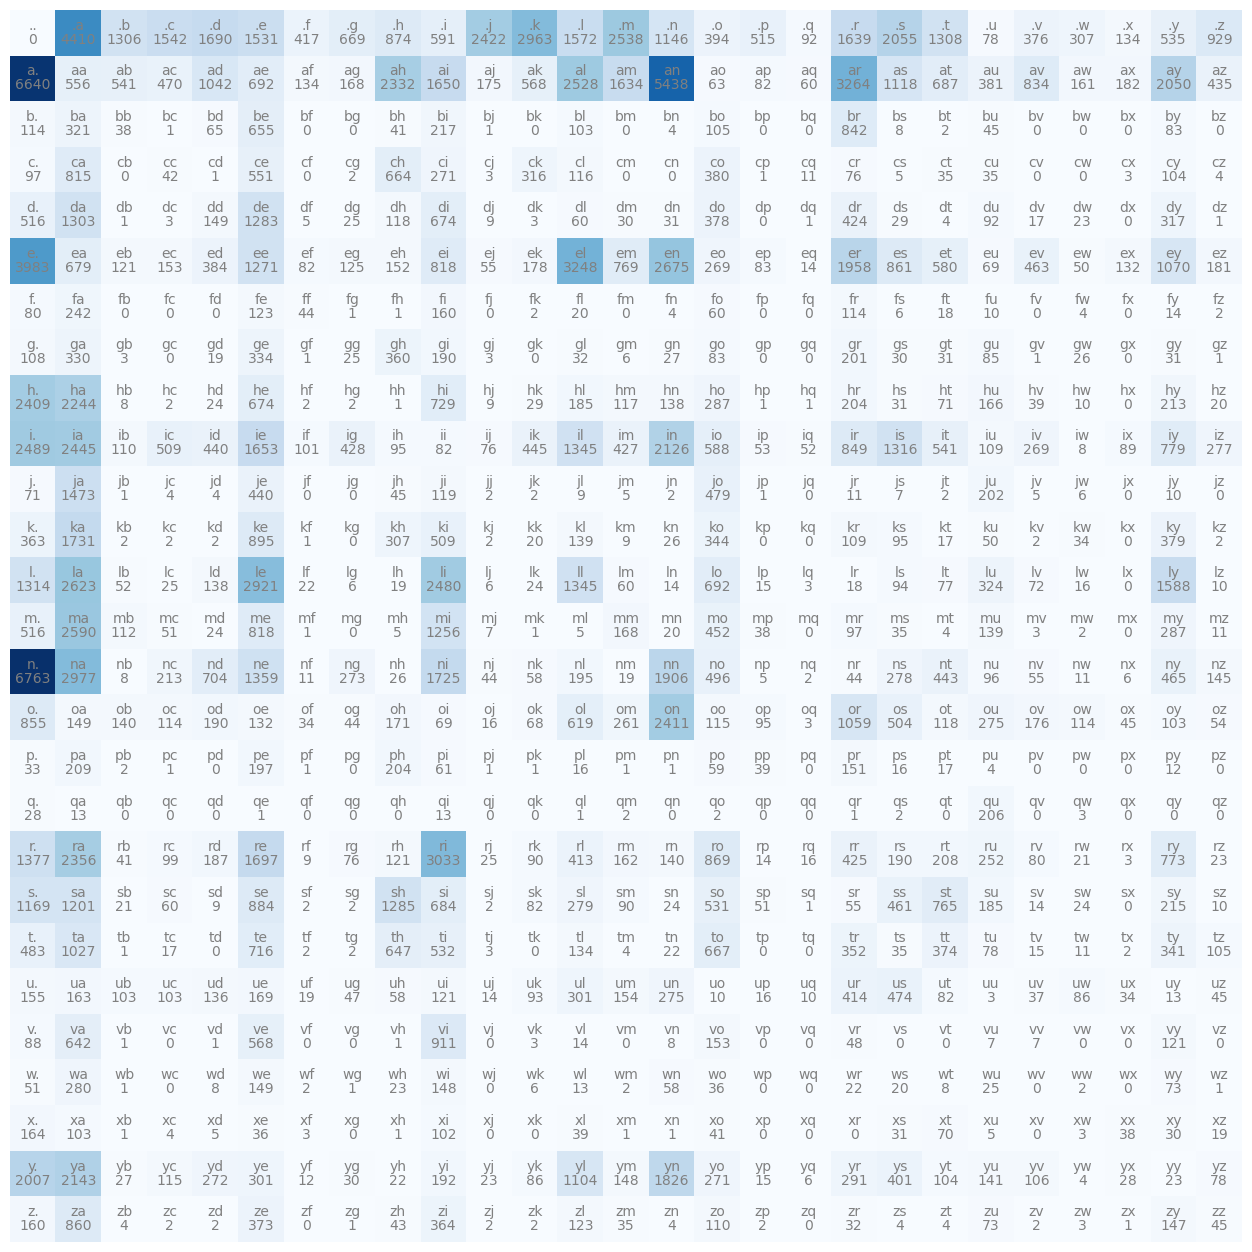

In [48]:
import matplotlib.pyplot as plt
%matplotlib inline
N=torch.zeros((27,27), dtype=torch.int32)  #26 char + 1 special chars
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)} #integer index and actual element of the list-enumerate-->mapping char to integer(first char is . so start from index 1)
stoi['.'] = 0
for w in words:
    chs = ['.']+list(w) +['.']
    for ch1, ch2 in zip(chs, chs[1:]):  #chs-><S> chs[1:]-><e>
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) +1 #.get returns count if none return 0 and add 1 regardless 
        # print(ch1,ch2)


itos = {i:s for s,i in stoi.items()}
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');


In [49]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [50]:
g = torch.Generator().manual_seed(2147483647) #lock the randomness
p = torch.rand(3, generator=g) #for 3 numbers usin above generator
p = p / p.sum() # get probability p/sum of p
p
#tensor([0.6064, 0.3033, 0.0903]) 60% of the samples to be 0, 30% to be 1, 3 times less 2's

tensor([0.6064, 0.3033, 0.0903])

In [51]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g) #generate samples from given probability allowing replacement i.e element to be considered again

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [54]:

g = torch.Generator().manual_seed(2147483647)
P = (N+1).float()
P /= P.sum(1, keepdims=True)
for i in range(10):
  
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [ ]:
#likelihood=>product of all probs
log_likelihood = 0.0
n = 0

for w in words:
#for w in ["andrejq"]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')